In [38]:
pip install langchain

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import os
from openai import OpenAI
from langchain.tools import tool

client = OpenAI(
    # This is the default and can be omitted
    api_key=os.environ.get("OPENAI_API_KEY"),
)

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
#response = llm.invoke("What is the capital of France?")
#print(response)

In [40]:
# 1. Define the State clearly
from typing_extensions import TypedDict #for entire State
from langchain_core.messages import AnyMessage #human or AI message
from typing import Annotated  #labeling
from langgraph.graph.message import add_messages #add messages is reducer in langgraph
from IPython.display import display,Image
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command,interrupt
memory=MemorySaver()

In [41]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    is_valid_question: bool
    summary: str
    selected_tables: list[str]
    Table_structure: list[str]
    sql_query: str
    results: str
    retry_sql_generation: int
    human_decision: str


def user_node(state: State):
    user_input = input("Please enter your question about the database: ")
    print("User Message: ", user_input)
    return {
        "messages": [HumanMessage(content=user_input)]
    }

In [42]:
from langchain_core.messages import SystemMessage

def Chatbot_With_Guardrail(state: State):
    system_prompt = SystemMessage(
        content=(
            "You are a classifier assistant. Your ONLY job is to determine whether the user's "
            "question is related to our healthcare database. The database contains: "
            "policy data, member data, and feed data. "
            "A question is considered relevant if it mentions or implies: "
            "policy numbers (e.g., P001), policy details, policy status, policy history, "
            "members, member names, member status, member history, coverage, enrollment, "
            "or TPA feeds (Quest, LabCorp, Aetna, Cigna etc). "
            "Examples of relevant questions include: "
            "'provide member name under policy P001', "
            "'show all active members', "
            "'what is the status of policy P010', "
            "'list Aetna feed entries for today'. "
            "If the user's question IS related, respond EXACTLY with: "
            "'Let me look into it and find the answer for you.' "
            "If the user's question is NOT related, respond EXACTLY with: "
            "'I can only answer questions related to healthcare policies, members, and feed data.' "
            "Do NOT answer the user's question. Only classify it. "
            "If user is requesting to update data in database, delete data in database, "
            "or change database structure or asking about how to update or delete data, "
            "respond EXACTLY with: 'Database update or delete is not allowed. I can provide information but cannot perform updates or deletions.'"
            "if there are generic question such as how is weather today and then respond with 'I can only answer questions related to healthcare policies, members, and feed data.'"
        )
    )

    messages = [system_prompt] + state["messages"]
    ai_msg = llm.invoke(messages)

    # --- Classification Logic ---
    text = ai_msg.content.strip()

    if text == "Let me look into it and find the answer for you.":
        is_valid_question = True
    elif text == "I can only answer questions related to healthcare policies, members, and feed data.":
        is_valid_question = False
    elif text == "Database update or delete is not allowed. I can provide information but cannot perform updates or deletions.":
        is_valid_question = False
    else:
        # Safety fallback: treat unknown output as invalid
        is_valid_question = False
    
    print("AI Message :",text)

    return {
    "messages": [ai_msg],
    "is_valid_question": is_valid_question
    }



In [43]:
def Router_Reset_OR_Summary(state: State):
    if state["is_valid_question"]:
        return "SummaryNode"
    else:
        return "Reset_Memory"   # loop back


In [44]:
from langchain_core.messages import RemoveMessage

def Reset_Memory(state: State):
    # 1. Gather the IDs of all existing messages
    existing_messages = state.get("messages", [])
    
    # 2. Create a RemoveMessage command for every message with an ID
    delete_commands = [
        RemoveMessage(id=msg.id) 
        for msg in existing_messages 
        if msg.id is not None
    ]
    
    # 3. Return the delete commands along with your other resets
    return {
        "messages": delete_commands, # This clears the message history!
        "is_valid_question": False,
        "summary": "",
        "selected_tables": [],
        "Table_structure": [],
        "results": "",
        "retry_sql_generation": 0,
        "human_decision": False
    }


In [45]:
def SummaryNode(state: State):
    conversation = "\n".join(m.content for m in state["messages"])
    summary_prompt = summary_prompt = f"""
    Summarize the conversation so far in 5–7 lines.
    Focus ONLY on the user's intent related to healthcare data.
    Conversation:
    {conversation}
    """
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    response = llm.invoke([HumanMessage(content=summary_prompt)]) 
    
    # Extract summary text
    summary = response.content.strip()
                          
    return {"summary": summary,
            "retry_sql_generation":0}

In [46]:
def Identify_Table(state: State):
    if not state["is_valid_question"]:
        return {"table": None}
    
    import sqlite3
    conn = sqlite3.connect("D:\\Gen AI Codes\\HealthcareDB.db")
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name;")
    rows = cur.fetchall()

    table_prompt = f"""
    Based on the {state["summary"]}, identify which table(s) in our healthcare database the user's question is referring to. 
    The database has the following tables: {', '.join(r[0] for r in rows)}.

    Respond with the name of the table(s) that are relevant to the user's question. If multiple tables are relevant, list them separated by commas. If no tables are relevant, respond with 'None'.
    """
    
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    tables= llm.invoke([HumanMessage(content=table_prompt)]).content.strip() 
    #print(table_prompt)
    print(f"*********Final question AI is trying to answer: {state['summary']}")
    print(f"*********Tables Identified by AI: {tables}")
    return {"selected_tables": tables}


In [47]:
def Get_Table_Structures(state: State):
    import sqlite3
    Table_structures = []
    for table in state["selected_tables"].split(","):
        table = table.strip()
        conn = sqlite3.connect("D:\\Gen AI Codes\\HealthcareDB.db")
        cur = conn.cursor()
        cur.execute("""
        SELECT sql
        FROM sqlite_master
        WHERE type='table' AND name=?;
        """,(table,))
        result = cur.fetchone()
        conn.close() 
        if result and result[0]:
            Table_structures.append(result[0].replace("\r\n", "\n"))
    #print(Table_structures)
    return {"Table_structure": Table_structures}


In [48]:
def Generate_Query(state: State):
    if not state["is_valid_question"]:
        return {"sql_query": None}
    
    query_prompt = f"""
    Based on the user's question (summary: {state["summary"]}) and the identified table structures ({'; '.join(state["Table_structure"])}), generate a SQL query that can be run against our healthcare database to retrieve the information needed to answer the user's question. 
    Only generate a SELECT query. Take only required columns in select clauses of SQL query. Do NOT generate any UPDATE, DELETE, or INSERT queries. If it's not possible to generate a valid SQL query based on the information, respond with 'Cannot generate query'.
    """
    
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    sql_query = llm.invoke([HumanMessage(content=query_prompt)]).content.strip()
    sql_query = (
        sql_query.replace("```sql", "")
               .replace("```", "")
               .strip()
    )
    print("*********Generated SQL Query: ", sql_query.replace("```\n", ""))
    return {"sql_query": sql_query}

In [49]:
from langchain_core.messages import AIMessage
def Guardrail_For_Query_Validation(state: State):
    sql = state.get("sql_query")
    if not sql or sql.lower() == "cannot generate query":
        return {"sql_query": None}
    
    # Basic safety check: only allow SELECT queries
    if not sql.strip().lower().startswith("select"):
        retries = state.get("retry_sql_generation", 0)
        # Create a message explaining the failure
        failure_msg = AIMessage(
        content=f"Query failed validation: The generated query did not start with 'SELECT'. Retrying... (Attempt {retries + 1})"
        )
        return {"sql_query": None, "retry_sql_generation": retries + 1,  "messages": [failure_msg]}
    return {"sql_query": sql}

In [50]:
def Router_Retry_OR_Execute_OR_Terminate(state: State):
    if state["sql_query"] is None:
        if state.get("retry_sql_generation", 0) >= 3:
            return "Terminate"
        else:
            return "Generate_Query"
    else:
        return "human_review_node"

In [51]:
def Terminate(state: State):
    print("AI Message: Sorry, I couldn't generate a valid SQL query after multiple attempts. Let's end this session.")
    interrupt()  # This will stop the graph execution

In [52]:
# The NODE function (updates the state)
def human_review_node(state: State):
    confirm = input("Execute this query? (yes/no/retry): ").lower()
    # Return a dictionary to update the state based on the user's decision
    return {"human_decision": confirm}

# The ROUTER function (tells the graph where to go)
def human_review_router(state: State):
    if state["human_decision"] == 'yes':
        return "Get_Results"
    else:
        return "Generate_Query"

In [53]:
def Get_Results(state: State):
    if not state["is_valid_question"] or not state["Table_structure"]:
        return {"results": None}
    
    sql = state.get("sql_query")
    import sqlite3
    conn = sqlite3.connect("D:\\Gen AI Codes\\HealthcareDB.db")
    cur = conn.cursor()
    try:
        cur.execute(sql)
        results = cur.fetchall()
    except Exception as e:
        results = f"Error executing query: {e}"
    conn.close() 
    print("*********Query Results: ", results)
    return {"results": results}

In [54]:
def Display_Results(state: State):
    display_prompt = f"""
    Based of summarry: {state["summary"]}, identified tables: {state["selected_tables"]}, and query results: {state["results"]}, generate a user-friendly response to answer the user's original question. If there were any errors in generating or executing the query, include that information in the response.
    """
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
    final_response = llm.invoke([HumanMessage(content=display_prompt)]).content.strip() 
    print("Final AI Response: ", final_response)
    
    

In [55]:
from langgraph.graph import StateGraph, add_messages
graph_builder=StateGraph(State)
graph_builder.add_node("user_node", user_node)
graph_builder.add_node("Chatbot_With_Guardrail", Chatbot_With_Guardrail)
graph_builder.add_node("Router_Reset_OR_Summary", Router_Reset_OR_Summary)
graph_builder.add_node("Reset_Memory", Reset_Memory)
graph_builder.add_node("SummaryNode", SummaryNode)
graph_builder.add_node("Identify_Table", Identify_Table)
graph_builder.add_node("Get_Table_Structures", Get_Table_Structures)
graph_builder.add_node("Generate_Query", Generate_Query)
graph_builder.add_node("human_review_node", human_review_node)
graph_builder.add_node("Get_Results", Get_Results)
graph_builder.add_node("Display_Results", Display_Results)
graph_builder.add_node("Guardrail_For_Query_Validation", Guardrail_For_Query_Validation)
graph_builder.add_node("Router_Retry_OR_Execute_OR_Terminate", Router_Retry_OR_Execute_OR_Terminate)
graph_builder.add_node("Terminate", Terminate)
graph_builder.add_edge(START,"user_node")
graph_builder.add_edge("user_node", "Chatbot_With_Guardrail")
graph_builder.add_conditional_edges("Chatbot_With_Guardrail", 
    Router_Reset_OR_Summary,
    {
        "SummaryNode": "SummaryNode",     # valid → continue pipeline
        "Reset_Memory": "Reset_Memory"              # invalid → loop back
    }
)
graph_builder.add_edge("Reset_Memory", "user_node")
graph_builder.add_edge("SummaryNode", "Identify_Table")
graph_builder.add_edge("Identify_Table", "Get_Table_Structures")
graph_builder.add_edge("Get_Table_Structures", "Generate_Query")
graph_builder.add_edge("Generate_Query", "Guardrail_For_Query_Validation")
graph_builder.add_conditional_edges("Guardrail_For_Query_Validation", Router_Retry_OR_Execute_OR_Terminate, {
    "Generate_Query": "Generate_Query",
    "human_review_node": "human_review_node",
    "Terminate": "Terminate"
})
graph_builder.add_conditional_edges(
    "human_review_node", 
    human_review_router, 
    {
        "Get_Results": "Get_Results",
        "Generate_Query": "Generate_Query"
    }
)
graph_builder.add_edge("Get_Results", "Display_Results")
graph_builder.add_edge("Terminate", END)
graph_builder.add_edge("Display_Results", END)
graph=graph_builder.compile(checkpointer=memory )

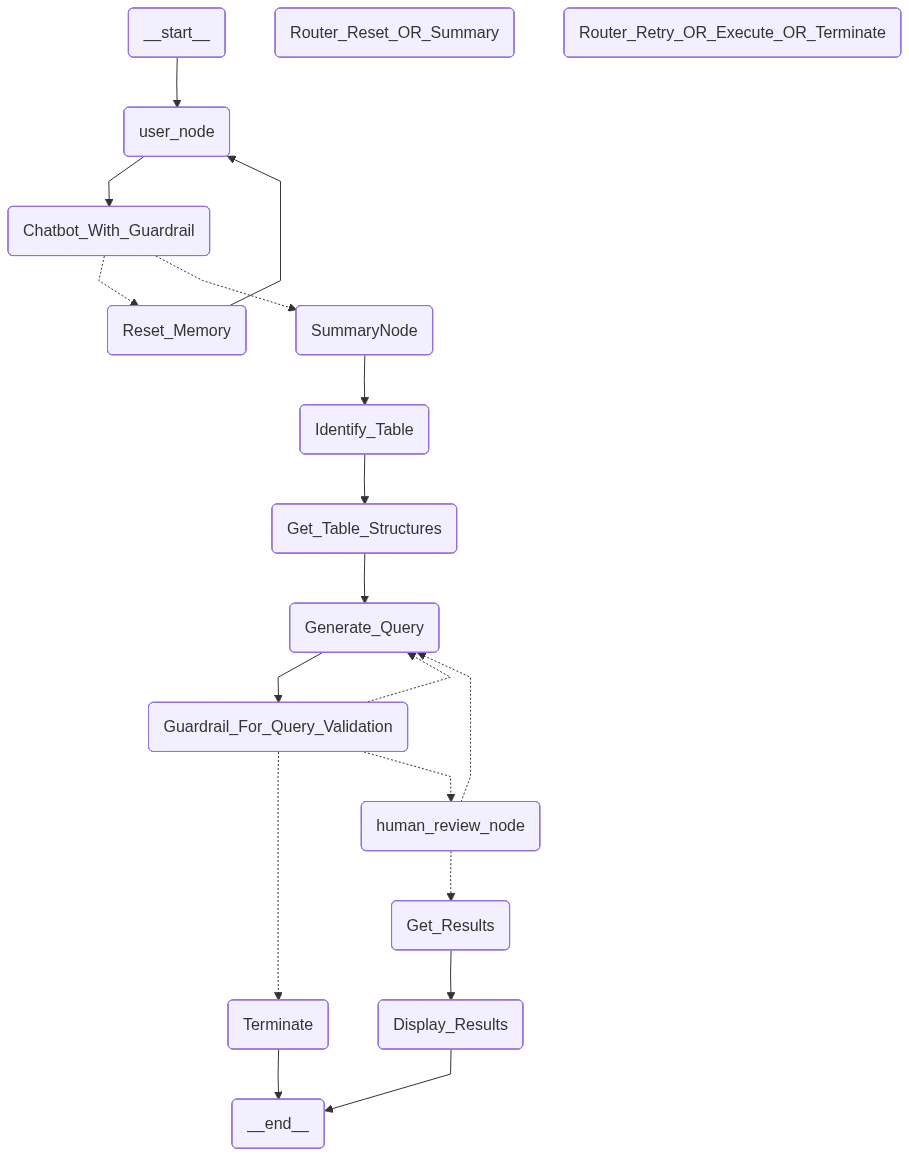

In [56]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Mermaid rendering not supported in this environment.")


In [57]:
import uuid
from langchain_core.messages import HumanMessage

# Generate a completely unique ID for this specific session
unique_thread_id = str(uuid.uuid4())

from langchain_core.messages import HumanMessage

print("Welcome to Database Querying with LLMs! You can ask questions about the database, \n"
"and I'll do my best to help you find the answers.")

result = graph.invoke(
    {"messages": [HumanMessage(content="You are helpful assistant.")]},
    config={"configurable": {"thread_id": "unique_thread_id"}}
)

Welcome to Database Querying with LLMs! You can ask questions about the database, 
and I'll do my best to help you find the answers.
User Message:  display all name and date of birth of members less than 35 years old
AI Message : Let me look into it and find the answer for you.
*********Final question AI is trying to answer: The user is requesting healthcare data specifically related to members who are under 35 years old. They want to see the names and dates of birth of these members. The intent is to filter and display demographic information based on age criteria within a healthcare dataset. The assistant acknowledged the request and is in the process of retrieving the relevant information.
*********Tables Identified by AI: Member, MemberHistory
*********Generated SQL Query:  SELECT first_name, last_name, birth_date
FROM Member
WHERE birth_date > DATE('now', '-35 years');
*********Query Results:  [('Emma', 'Thompson', '2010-06-22'), ('Liam', 'Thompson', '2014-09-15'), ('Ava', 'Johnso